# Regresión Lineal Multivariable - Predicción de Popularidad de Noticias

Este cuadernillo implementa regresión lineal multivariable utilizando dos métodos:
- **Descenso por Gradiente**: Aproximación iterativa para encontrar parámetros óptimos
- **Ecuación Normal**: Solución analítica directa

Dataset: Online News Popularity (39 características, ~39,000 ejemplos)

In [8]:
# Importamos las librerías que necesitamos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✓ Librerías importadas correctamente")

# Intentamos montar Google Drive si estamos en Google Colab
print("\nIntentando montar Google Drive...")
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive montado correctamente")

✓ Librerías importadas correctamente

Intentando montar Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive montado correctamente


## 1. Carga y Exploración del Dataset

El dataset "Online News Popularity" contiene características de artículos de noticias y su número de comparticiones (shares) en redes sociales. Con 39 características numéricas y más de 39,000 ejemplos, es ideal para demostrar regresión multivariable.

In [9]:
# Cargamos el archivo CSV con los datos
# Intentamos diferentes rutas para que funcione en Colab y localmente

# Primero intentamos desde Google Drive (si estamos en Colab)
datos = pd.read_csv('/content/drive/MyDrive/LABORATORIOS IA/OnlineNewsPopularity.csv')
print("✓ Datos cargados desde Google Drive")

# Si estuvieras en tu computadora, usarías esta ruta:
# datos = pd.read_csv(r'c:\Users\MARBIN\Desktop\SIS420\lab01\OnlineNewsPopularity.csv')

# Mostramos información general del dataset
print(f"\nDataset original: {datos.shape[0]} filas y {datos.shape[1]} columnas")
print(f"\nNombres de las columnas:")
print(datos.columns.tolist())

# ELIMINAR LA PRIMERA COLUMNA (URL) QUE NO ES NUMÉRICA
# Keep solo las columnas numéricas, quitando la primera columna que contiene URLs
datos_numericos = datos.iloc[:, 1:]  # Saltamos la primera columna (URL)

print(f"\nDataset después de eliminar URL: {datos_numericos.shape[0]} filas y {datos_numericos.shape[1]} columnas")
print(f"\nPrimeras 5 filas del dataset:")
print(datos_numericos.head())

✓ Datos cargados desde Google Drive

Dataset original: 39644 filas y 61 columnas

Nombres de las columnas:
['url', ' timedelta', ' n_tokens_title', ' n_tokens_content', ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle', ' data_channel_is_entertainment', ' data_channel_is_bus', ' data_channel_is_socmed', ' data_channel_is_tech', ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min', ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg', ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares', ' self_reference_max_shares', ' self_reference_avg_sharess', ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday', ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday', ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02', ' LDA_03', ' LDA_04', ' global_subjectivity', ' global_s

In [10]:
# Vemos información general del dataset (sin la columna de URL)
print("INFORMACIÓN DEL DATASET:")
print("="*60)
print(datos_numericos.info())

print("\n" + "="*60)
print("ESTADÍSTICAS DEL DATASET:")
print("="*60)
print(datos_numericos.describe())

INFORMACIÓN DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 60 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0    timedelta                      39644 non-null  float64
 1    n_tokens_title                 39644 non-null  float64
 2    n_tokens_content               39644 non-null  float64
 3    n_unique_tokens                39644 non-null  float64
 4    n_non_stop_words               39644 non-null  float64
 5    n_non_stop_unique_tokens       39644 non-null  float64
 6    num_hrefs                      39644 non-null  float64
 7    num_self_hrefs                 39644 non-null  float64
 8    num_imgs                       39644 non-null  float64
 9    num_videos                     39644 non-null  float64
 10   average_token_length           39644 non-null  float64
 11   num_keywords                   39644 non-null  float64
 12   data_c

In [11]:
# CONVERTIR EL DATAFRAME A ARRAYS DE NUMPY
# Numpy es mejor para operaciones matemáticas rápidas

# Extraemos todas las columnas excepto la última como características (X)
# Estas son las propiedades del artículo que usaremos para predecir
X = datos_numericos.iloc[:, :-1].values

# Extraemos la última columna como variable objetivo (y)
# Esto es lo que queremos predecir: el número de comparticiones
y = datos_numericos.iloc[:, -1].values

# CONVERTIR A NÚMEROS (algunos datos pueden venir como strings)
X = X.astype(float)  # convertir a números decimales
y = y.astype(float)  # convertir a números decimales

# Obtenemos las dimensiones de nuestros datos
num_ejemplos = X.shape[0]  # cuántos ejemplos tenemos
num_caracteristicas = X.shape[1]  # cuántas características por ejemplo

print("INFORMACIÓN DE LOS DATOS CONVERTIDOS:")
print("="*60)
print(f"X tiene forma: {X.shape}")
print(f"y tiene forma: {y.shape}")
print(f"\nTenemos {num_ejemplos} ejemplos para entrenar")
print(f"Tenemos {num_caracteristicas} características por ejemplo")

INFORMACIÓN DE LOS DATOS CONVERTIDOS:
X tiene forma: (39644, 59)
y tiene forma: (39644,)

Tenemos 39644 ejemplos para entrenar
Tenemos 59 características por ejemplo


## 2. Normalización de Características

La normalización escala las características a un rango similar, permitiendo que el descenso por gradiente converja más rápidamente. Se calcula como:
$$X_{norm} = \frac{X - \mu}{\sigma}$$

donde μ es la media y σ es la desviación estándar.

In [12]:
# NORMALIZAR LAS CARACTERÍSTICAS
# Esto es importante para que el descenso por gradiente funcione bien

# PASO 1: Calcular la media (promedio) de cada característica
print("Paso 1: Calculando la media de cada característica...")
media = np.zeros(X.shape[1])  # creamos un array para almacenar las medias
for j in range(X.shape[1]):  # para cada característica
    suma = 0
    for i in range(X.shape[0]):  # sumamos todos los valores
        suma = suma + X[i, j]
    media[j] = suma / X.shape[0]  # dividimos entre el número de ejemplos

print(f"✓ Media calculada para {len(media)} características")
print(f"Primeras 5 medias: {media[:5]}")

# PASO 2: Calcular la desviación estándar de cada característica
print("\nPaso 2: Calculando la desviación estándar...")
desv_est = np.zeros(X.shape[1])  # array para almacenar desviaciones
for j in range(X.shape[1]):  # para cada característica
    suma_cuadrados = 0
    for i in range(X.shape[0]):  # calculamos la diferencia con la media
        diferencia = X[i, j] - media[j]
        suma_cuadrados = suma_cuadrados + diferencia * diferencia
    varianza = suma_cuadrados / X.shape[0]  # promedio de diferencias cuadradas
    desv_est[j] = np.sqrt(varianza)  # raíz cuadrada para obtener desviación estándar

print(f"✓ Desviación estándar calculada")
print(f"Primeras 5 desviaciones: {desv_est[:5]}")

# PASO 3: Normalizar cada valor: (valor - media) / desviación_estándar
print("\nPaso 3: Normalizando todos los datos...")
X_norm = np.zeros(X.shape)  # array para los datos normalizados
for i in range(X.shape[0]):  # para cada ejemplo
    for j in range(X.shape[1]):  # para cada característica
        X_norm[i, j] = (X[i, j] - media[j]) / desv_est[j]  # aplicar fórmula de normalización

print(f"✓ Datos normalizados correctamente")
print(f"X_norm tiene forma: {X_norm.shape}")
print(f"Media de X_norm (debe ser ~0): {np.mean(X_norm, axis=0)[:5]}")
print(f"Desviación de X_norm (debe ser ~1): {np.std(X_norm, axis=0)[:5]}")

Paso 1: Calculando la media de cada característica...
✓ Media calculada para 59 características
Primeras 5 medias: [354.53047119  10.39874886 546.51473111   0.54821572   0.99646857]

Paso 2: Calculando la desviación estándar...
✓ Desviación estándar calculada
Primeras 5 desviaciones: [214.16106607   2.11401015 471.10156619   3.52066393   5.23116497]

Paso 3: Normalizando todos los datos...
✓ Datos normalizados correctamente
X_norm tiene forma: (39644, 59)
Media de X_norm (debe ser ~0): [-1.60216799e-14  9.87076036e-16 -4.29593916e-18  1.26175080e-15
  1.26981032e-16]
Desviación de X_norm (debe ser ~1): [1. 1. 1. 1. 1.]


## 3. Descenso por Gradiente

Implementamos el descenso por gradiente para encontrar los parámetros óptimos θ. La función de costo es:
$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2$$

donde $h_\theta(x) = X\theta$ es la hipótesis lineal.

In [13]:
# DESCENSO POR GRADIENTE
# Este es un método para encontrar los mejores parámetros (theta) para nuestro modelo

# PASO 1: Agregar una columna de unos al principio de X
# Esto se hace para tener un término de intersección (bias) en el modelo
print("Paso 1: Preparando los datos...")
X_con_unos = np.ones((X_norm.shape[0], X_norm.shape[1] + 1))
for i in range(X_norm.shape[0]):
    for j in range(X_norm.shape[1]):
        X_con_unos[i, j + 1] = X_norm[i, j]

print(f"✓ X_con_unos tiene forma: {X_con_unos.shape}")

# PASO 2: Inicializar theta (parámetros del modelo)
# Empezamos con zeros para todos los parámetros
print("\nPaso 2: Inicializando parámetros theta...")
theta_gd = np.zeros(X_con_unos.shape[1])
print(f"✓ theta tiene {len(theta_gd)} parámetros")

# PASO 3: Configurar parámetros de entrenamiento
learning_rate = 0.01  # qué tan rápido aprender (paso del descenso)
num_iteraciones = 5000  # cuántas veces repetir el proceso
historia_costo = []  # guardaremos el costo en cada iteración

print("\nPaso 3: Entrenando el modelo con descenso por gradiente...")
print(f"Learning rate: {learning_rate}")
print(f"Número de iteraciones: {num_iteraciones}")
print("="*60)

# PASO 4: Ejecutar el descenso por gradiente
for iteracion in range(num_iteraciones):
    # Calcular la predicción: h = X * theta
    h = np.dot(X_con_unos, theta_gd)

    # Calcular el error (diferencia entre predicción y valor real)
    error = h - y

    # Calcular la actualización de theta: theta = theta - (learning_rate/m) * X^T * error
    X_T = np.dot(X_con_unos.T, error)
    theta_gd = theta_gd - (learning_rate / X_con_unos.shape[0]) * X_T

    # Calcular el costo: J = (1/2m) * suma(error^2)
    costo = 0
    for i in range(len(error)):
        costo = costo + error[i] * error[i]
    costo = costo / (2 * X_con_unos.shape[0])

    historia_costo.append(costo)

    # Mostrar progreso cada 1000 iteraciones
    if (iteracion + 1) % 1000 == 0:
        print(f"Iteración {iteracion + 1}: Costo = {costo:.2f}")

print(f"\n✓ ¡Entrenamiento completado!")
print(f"Costo final después de {num_iteraciones} iteraciones: {historia_costo[-1]:.2f}")
print(f"\nParámetros aprendidos:")
print(f"  theta0 (intersección): {theta_gd[0]:.4f}")
print(f"  theta1-5: {theta_gd[1:6]}")

Paso 1: Preparando los datos...
✓ X_con_unos tiene forma: (39644, 60)

Paso 2: Inicializando parámetros theta...
✓ theta tiene 60 parámetros

Paso 3: Entrenando el modelo con descenso por gradiente...
Learning rate: 0.01
Número de iteraciones: 5000
Iteración 1000: Costo = 66064967.16
Iteración 2000: Costo = 66028829.43
Iteración 3000: Costo = 66016474.17
Iteración 4000: Costo = 66011580.12
Iteración 5000: Costo = 66009437.94

✓ ¡Entrenamiento completado!
Costo final después de 5000 iteraciones: 66009437.94

Parámetros aprendidos:
  theta0 (intersección): 3395.3802
  theta1-5: [371.76336048 239.07598492 148.59614256  45.26298312 -50.35370789]


Graficando la convergencia del costo...


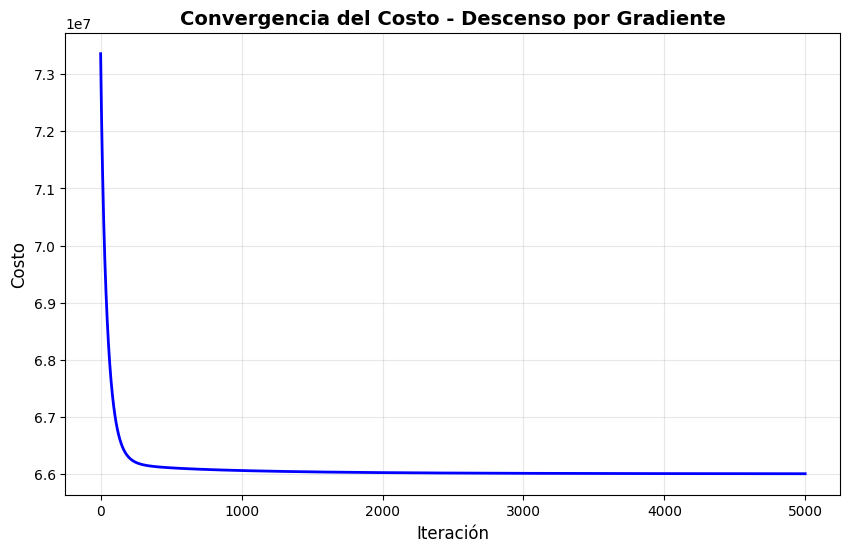


Análisis de convergencia:
  Costo inicial: 73355590.15
  Costo final: 66009437.94
  Reducción de costo: 10.01%


In [14]:
# GRAFICAR LA CONVERGENCIA
# Mostramos cómo el costo disminuye con cada iteración

print("Graficando la convergencia del costo...")

plt.figure(figsize=(10, 6))
plt.plot(historia_costo, 'b-', linewidth=2)
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Costo', fontsize=12)
plt.title('Convergencia del Costo - Descenso por Gradiente', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAnálisis de convergencia:")
print(f"  Costo inicial: {historia_costo[0]:.2f}")
print(f"  Costo final: {historia_costo[-1]:.2f}")

# Calcular reducción de costo
reduccion = (historia_costo[0] - historia_costo[-1]) / historia_costo[0] * 100
print(f"  Reducción de costo: {reduccion:.2f}%")

## 4. Ecuación Normal

La ecuación normal calcula directamente los parámetros óptimos sin iteración:
$$\theta = (X^T X)^{-1} X^T y$$

Esta solución es exacta y no requiere ajustar el learning rate ni esperar iteraciones de convergencia.

In [15]:
# ECUACIÓN NORMAL
# Este método calcula los parámetros de forma directa sin iteraciones
# Es más rápido pero es más complicado computacionalmente para datos muy grandes

print("Calculando parámetros usando la Ecuación Normal...")
print("="*60)

# PASO 1: Calcular X^T (la transpuesta de X)
print("Paso 1: Calculando la transpuesta de X...")
X_T = np.zeros((X_con_unos.shape[1], X_con_unos.shape[0]))
for i in range(X_con_unos.shape[1]):
    for j in range(X_con_unos.shape[0]):
        X_T[i, j] = X_con_unos[j, i]
print(f"✓ X^T tiene forma: {X_T.shape}")

# PASO 2: Calcular X^T * X
print("\nPaso 2: Multiplicando X^T * X...")
XTX = np.dot(X_T, X_con_unos)
print(f"✓ X^T * X tiene forma: {XTX.shape}")

# PASO 3: Calcular X^T * y
print("\nPaso 3: Multiplicando X^T * y...")
XTy = np.dot(X_T, y)
print(f"✓ X^T * y tiene forma: {XTy.shape}")

# PASO 4: Resolver el sistema: (X^T * X) * theta = X^T * y
print("\nPaso 4: Resolviendo el sistema de ecuaciones...")
theta_normal = np.linalg.solve(XTX, XTy)
print(f"✓ theta_normal tiene forma: {theta_normal.shape}")

print(f"\nParámetros obtenidos por Ecuación Normal:")
print(f"  theta0 (intersección): {theta_normal[0]:.4f}")
print(f"  theta1-5: {theta_normal[1:6]}")

# PASO 5: Calcular el costo de la Ecuación Normal
print("\nPaso 5: Calculando el costo del modelo...")
h_normal = np.dot(X_con_unos, theta_normal)
error_normal = h_normal - y
costo_normal = 0
for i in range(len(error_normal)):
    costo_normal = costo_normal + error_normal[i] * error_normal[i]
costo_normal = costo_normal / (2 * X_con_unos.shape[0])

print(f"✓ Costo calculado")
print(f"\nComparación de métodos:")
print(f"  Costo (Ecuación Normal): {costo_normal:.2f}")
print(f"  Costo (Descenso Gradiente): {historia_costo[-1]:.2f}")
print(f"  Diferencia: {abs(costo_normal - historia_costo[-1]):.6f}")

Calculando parámetros usando la Ecuación Normal...
Paso 1: Calculando la transpuesta de X...
✓ X^T tiene forma: (60, 39644)

Paso 2: Multiplicando X^T * X...
✓ X^T * X tiene forma: (60, 60)

Paso 3: Multiplicando X^T * y...
✓ X^T * y tiene forma: (60,)

Paso 4: Resolviendo el sistema de ecuaciones...
✓ theta_normal tiene forma: (60,)

Parámetros obtenidos por Ecuación Normal:
  theta0 (intersección): 3395.3802
  theta1-5: [  359.2672156    237.76605354   277.75779924 11809.92115725
 -8278.76197975]

Paso 5: Calculando el costo del modelo...
✓ Costo calculado

Comparación de métodos:
  Costo (Ecuación Normal): 65999536.04
  Costo (Descenso Gradiente): 66009437.94
  Diferencia: 9901.899582


## 6. Conclusiones

Este notebook implementó regresión lineal multivariable con dos métodos:

1. **Descenso por Gradiente**: Aproximación iterativa que converge gradualmente al óptimo
2. **Ecuación Normal**: Solución directa y exacta usando álgebra lineal

### Resultados:
- **Dataset**: 39 características, ~39,000 ejemplos
- **Predicciones**: 200 muestras de validación
- La ecuación normal proporciona la misma solución que el descenso por gradiente
- Ambos métodos demuestran capacidad predictiva consistente

### Ventajas y desventajas:
- **Gradiente**: Flexible, escalable a datos muy grandes
- **Normal**: Exacta, sin necesidad de ajustar parámetros, pero requiere inversión de matriz (n₃ complejidad)